In [21]:
import numpy as np
import matplotlib.pyplot as plt

from cued_sf2_lab.familiarisation import load_mat_img, plot_image

# 12. Combined run-length / Huffman coding methods

Up to now we have used **entropy** as a proxy for the compressed size. Here we build the
real bit-stream and measure the size we can actually achieve.

Huffman codes are efficient when no single symbol has probability much above 50%. But after
any energy-compaction transform, _most_ quantised coefficients are zero — and that "zero"
event has probability far above 50% (which is exactly why high compression is possible).
The JPEG run-length / Huffman scheme is the standard trick for coding such heavily-skewed
data efficiently.


**Roadmap**

1. **§12.1 — the scheme.** How a block of quantised coefficients becomes a bit-stream
   (run-length + log-amplitude + Huffman).
2. **§12.2 — in practice.** The `jpeg.py` helpers, then encode → decode → verify on a real image.
3. **Optimised Huffman tables.** Is designing a per-image table worth the cost of sending it?
4. **Beyond JPEG.** Adapting the scan so the same coder works for LBT and DWT front-ends.


## 12.1 The baseline JPEG scheme

Each non-zero coefficient is coded together with **the number of zeros preceding it**, as a
single event. For the example sequence

$$
3,\; 0, 0, -2,\; 0, 0, 0, 1,\; 0, -3,\; -1,\; 0, 0, 0, 0, 1, \ldots
$$

the six events are:

```
0 zeros, 3
2 zeros, -2
3 zeros, 1
1 zero, -3
0 zeros, -1
4 zeros, 1
```

To keep the code small, JPEG does not Huffman-code the value itself. It codes a **(run, size)**
symbol, where `run` is the zero-count (capped at 15) and `size` is the number of bits (1-10) for the magnitude; the value's magnitude and sign bits are then appended **raw**. That gives

- 16 runs × 10 sizes = 160 symbols
- **EOB** (rest of block is zero)
- **ZRL** (a run of 16 zeros)

hence **162 symbols** total.

Per 8×8 block: the **DC** coefficient is sent first (a fixed-length word here), then the 63
**AC** coefficients are read in a **zig-zag** scan — low frequencies (usually non-zero) first,
so the high-frequency tail of zeros collapses into a single EOB.


### From coefficients to bits: three stages

The jump _coefficients → bit-stream_ is really three stages — the middle one produces a table
you never see in the output, which is what makes it feel opaque:

1. **Scan** — read the quantised block zig-zag into a 1-D sequence (mostly zeros).
2. **`runampl`** — collapse each zero-run + following non-zero into one **`(run, size, value)`**
   row (plus a final **EOB** row). `value` is the magnitude in offset binary.
3. **`huffenc`** — emit, per row, the **Huffman codeword for `(run, size)`** followed
   immediately by the **`size` raw bits of the value**.

So one non-zero coefficient becomes **two `vlc` rows**: `[Huffman code for (run,size)]` then
`[raw value, size]`. Only `(run, size)` is Huffman-coded (162 possible symbols → a tiny table);
the value rides along raw, because within a fixed `size` its bits are essentially random and
would not compress anyway.

The next cell runs all three stages on the example sequence above.


In [22]:
# The three coding stages on the handout's own example AC sequence (from section 12.1 above).
from cued_sf2_lab.jpeg import runampl, huffdflt, huffgen

# A quantised AC sequence (zig-zag scanned, mostly zeros):
seq = np.array([3, 0, 0, -2, 0, 0, 0, 1, 0, -3, -1, 0, 0, 0, 0, 1])
real = seq[seq != 0]                    # the actual non-zero coefficients, in order

# STAGE 1: runampl collapses zero-runs into one (run, size, value) row per non-zero coeff (+ EOB).
# `value` is the offset-binary bit pattern; (=N) is the real signed coefficient it encodes.
rsa = runampl(seq)
print("STAGE 1  runampl  ->  (run, size, value) rows, one per non-zero coefficient")
k = 0
for run, size, val in rsa:
    if size == 0:
        print(f"   run={run}  size={size}                 ->  EOB (end of block)")
    else:
        bits = format(int(val), '0{}b'.format(int(size)))
        print(f"   run={run}  size={size}  value={bits:<4} (={real[k]})")
        k += 1

STAGE 1  runampl  ->  (run, size, value) rows, one per non-zero coefficient
   run=0  size=2  value=11   (=3)
   run=2  size=2  value=01   (=-2)
   run=3  size=1  value=1    (=1)
   run=1  size=2  value=00   (=-3)
   run=0  size=1  value=0    (=-1)
   run=4  size=1  value=1    (=1)
   run=0  size=0                 ->  EOB (end of block)


next, we turn each combination of `(run,size)` into symbol, and a huffman codeword. this codeword mapping is fixed (we don't build a custom huffman table for this sequence of coefficients!)


In [23]:
# STAGE 2: walk the rows IN ORDER; each emits a Huffman code for (run,size), THEN the raw value.
_, ehuf = huffgen(huffdflt(1))          # ehuf[symbol] = [codeword, num_bits]
print("\nSTAGE 2  each event in order  ->  Huffman code for (run,size), THEN raw value bits:")
stream = []
k = 0
for run, size, val in rsa:
    sym = run * 16 + size               # the (run, size) symbol, 0..255
    code, nbits = ehuf[sym]
    hcode = format(int(code), '0{}b'.format(int(nbits)))
    if size == 0:                       # EOB: Huffman code only, no value
        print(f"   EOB                symbol {sym:3d}  ->  Huffman {hcode}")
        stream.append(hcode)
    else:
        vbits = format(int(val), '0{}b'.format(int(size)))
        print(f"   (run={run}, size={size}) -> symbol {sym:3d}  =>  Huffman {hcode:<8} + value {vbits:<2} (={real[k]})")
        stream += [hcode, vbits]
        k += 1

# The vlc rows are exactly these pieces, concatenated in this order.
print("\nfull AC bitstream, in order:")
print("   " + " ".join(stream))
print(f"total AC bits = {sum(len(s) for s in stream)}")


STAGE 2  each event in order  ->  Huffman code for (run,size), THEN raw value bits:
   (run=0, size=2) -> symbol   2  =>  Huffman 01       + value 11 (=3)
   (run=2, size=2) -> symbol  34  =>  Huffman 11111001 + value 01 (=-2)
   (run=3, size=1) -> symbol  49  =>  Huffman 111010   + value 1  (=1)
   (run=1, size=2) -> symbol  18  =>  Huffman 11011    + value 00 (=-3)
   (run=0, size=1) -> symbol   1  =>  Huffman 00       + value 0  (=-1)
   (run=4, size=1) -> symbol  65  =>  Huffman 111011   + value 1  (=1)
   EOB                symbol   0  ->  Huffman 1010

full AC bitstream, in order:
   01 11 11111001 01 111010 1 11011 00 00 0 111011 1 1010
total AC bits = 42


### Where the codewords come from

Two different numbers appeared above, fixed in two different ways:

- **Symbol number = `run × 16 + size`** — just packs the two small numbers into one byte
  (run in the high nibble 0–15, size in the low nibble 0–10). So (run 2, size 2) → 34;
  EOB = (0,0) → 0; ZRL = (15,0) → 240. The decoder reverses it by arithmetic
  (`run = sym // 16`, `size = sym % 16`) — nothing is transmitted.
- **Symbol → codeword** comes from a **Huffman table**. `huffdflt(1)` is the _standard JPEG
  luminance AC table, hardcoded in `jpeg.py`_. Encoder and decoder both call it and build the
  identical `ehuf`, so they already agree — again nothing is sent. (Only `opthuff=True`
  designs a custom table from the image's own statistics, and _that_ must be transmitted.)

**Why do the code lengths look so uneven** when every symbol in the toy example appears
exactly once? Because the lengths are **not** computed from this sequence — they come from the
fixed JPEG table, tuned on the statistics of _many real photographs_, where (run 0, size 1/2)
is genuinely very common (2-bit code) and (run 2, size 2) is rare (8-bit code). For this tiny
**uniform** example that table is far from optimal, as the next cell shows.


In [24]:
# The toy symbols all occur once (uniform), yet the default table gives them very different
# lengths -- because that table is tuned on real images, not on this sequence.
import math
print("symbol  (run,size)   default-table code length")
for run, size, _ in rsa:
    sym = run * 16 + size
    print(f"  {sym:3d}      ({run},{size})          {ehuf[sym][1]} bits")

n = len(rsa)                                            # distinct events (incl. EOB), each used once
used = sum(int(ehuf[run * 16 + size][1]) for run, size, _ in rsa)
opt_len = math.ceil(math.log2(n))
print(f"\ndefault JPEG table : {used} bits for these {n} symbols")
print(f"optimal for this UNIFORM toy: ~{opt_len} bits each = ~{opt_len * n} bits")
print("-> on this tiny uniform example the default table is wasteful; huffdes()/opthuff=True")
print("   would build the optimal tree for the actual data (at the cost of sending it).")

symbol  (run,size)   default-table code length
    2      (0,2)          2 bits
   34      (2,2)          8 bits
   49      (3,1)          6 bits
   18      (1,2)          5 bits
    1      (0,1)          2 bits
   65      (4,1)          6 bits
    0      (0,0)          4 bits

default JPEG table : 33 bits for these 7 symbols
optimal for this UNIFORM toy: ~3 bits each = ~21 bits
-> on this tiny uniform example the default table is wasteful; huffdes()/opthuff=True
   would build the optimal tree for the actual data (at the cost of sending it).


### Decoding a gapless stream

The `vlc` bits are concatenated with no delimiters, yet are unambiguously parseable:

1. **Huffman codes are prefix-free** — no codeword is a prefix of another — so the decoder
   reads bits until they match _some_ codeword; that match marks the codeword's end.
2. The decoded symbol gives **`size`**, which says exactly how many raw value bits follow.

So each codeword announces the length of what comes next, and **EOB** ends the block — the
stream is self-describing. Walking the example bitstream (shown spaced, but really gapless):

| read bits  | matches → symbol     | `size` | then read | value |
| ---------- | -------------------- | :----: | --------- | :---: |
| `01`       | 2 = (run 0, size 2)  |   2    | `11`      |   3   |
| `11111001` | 34 = (run 2, size 2) |   2    | `01`      |  −2   |
| `111010`   | 49 = (run 3, size 1) |   1    | `1`       |   1   |
| `11011`    | 18 = (run 1, size 2) |   2    | `00`      |  −3   |
| `00`       | 1 = (run 0, size 1)  |   1    | `0`       |  −1   |
| `111011`   | 65 = (run 4, size 1) |   1    | `1`       |   1   |
| `1010`     | 0 = **EOB**          |   0    | —         |  end  |


## 12.2 The `jpeg.py` helpers

You won't normally call these one by one — **`jpegenc`** chains them (DCT → `quant1` →
zig-zag scan → `runampl` → `huffenc`) into the `vlc` bit-stream, and **`jpegdec`** runs the
exact inverse. The pieces:

- `jpegenc` / `jpegdec` — full simplified-JPEG encode / decode.
- `quant1` / `quant2` — quantise to integer step numbers / reconstruct (together ≡ `quantise`).
- `runampl` — coefficients → `(run, size, value)` rows.
- `huffenc` — `(run, size, value)` rows → `vlc` codewords.
- `huffdflt` — the default JPEG luminance/chrominance tables (App. K.3.3.2).
- `huffdes` — design an optimised table from a usage histogram.
- `huffgen` — build the `huffcode` / `ehuf` lookup from a table.

The walkthrough below just calls `jpegenc` and `jpegdec` and inspects what they produce.


In [25]:
from cued_sf2_lab.jpeg import (
    jpegenc, jpegdec, quant1, quant2, huffenc, huffdflt, huffdes, huffgen)

**`vlc` format.** The conceptual bit-stream is exactly what stage 2 built:
`[Huffman(run,size)][raw value][Huffman(run,size)][raw value]…[EOB]…` concatenated.

For fast decoding we don't pack it into literal bits — we chop it at every field boundary and store each
field (either huffman code or raw value) as one **row** `[value as integer, number of bits]`.

So a row is **one field** (a Huffman codeword, _or_ a raw value, _or_ a DC word) — a single
non-zero coefficient takes two rows (its codeword, then its raw value).

To recover the real bit-stream you'd write each row's `value` out in `number of bits` binary digits and concatenate.
The packed stream is never actually built, but its size is just the sum of the lengths, `vlc[:, 1].sum()`.


### Encoding an image

Call `vlc, hufftab = jpegenc(X, qstep)`, then look at the coded size, the structure of `vlc`,
and the table it used (`dict(zip(hufftab.huffval, hufftab.codes))`).


In [26]:
X, _ = load_mat_img(img='lighthouse.mat', img_info='X')
qstep = 17

# Simplified baseline-JPEG encode: 8x8 DCT -> centre-clipped quantiser -> run-length / Huffman.
vlc, hufftab = jpegenc(X, qstep)
print(f'Coded size = {vlc[:, 1].sum()} bits  ({vlc[:, 1].sum() / X.size:.3f} bits/pixel)')

# vlc is the DATA: one row per codeword [value, num_bits]. First rows of the first block:
print('\nfirst vlc rows  [value, bits]:')
print(vlc[:6])

Forward 8 x 8 DCT
Quantising to step size of 17
Generating huffcode and ehuf using default tables
Coding rows
Bits for coded image = 67605
Coded size = 67605 bits  (1.032 bits/pixel)

first vlc rows  [value, bits]:
[[183   8]
 [  0   2]
 [  0   1]
 [  0   2]
 [  1   1]
 [ 10   4]]


In [27]:
# hufftab is the CODEBOOK: the 162 (run,size) symbols -> Huffman codewords.
#default jpeg table is shown
dict(zip(hufftab.huffval, hufftab.codes))

{np.uint8(1): bitword(0b00, 2),
 np.uint8(2): bitword(0b01, 2),
 np.uint8(3): bitword(0b100, 3),
 np.uint8(0): bitword(0b1010, 4),
 np.uint8(4): bitword(0b1011, 4),
 np.uint8(17): bitword(0b1100, 4),
 np.uint8(5): bitword(0b11010, 5),
 np.uint8(18): bitword(0b11011, 5),
 np.uint8(33): bitword(0b11100, 5),
 np.uint8(49): bitword(0b111010, 6),
 np.uint8(65): bitword(0b111011, 6),
 np.uint8(6): bitword(0b1111000, 7),
 np.uint8(19): bitword(0b1111001, 7),
 np.uint8(81): bitword(0b1111010, 7),
 np.uint8(97): bitword(0b1111011, 7),
 np.uint8(7): bitword(0b11111000, 8),
 np.uint8(34): bitword(0b11111001, 8),
 np.uint8(113): bitword(0b11111010, 8),
 np.uint8(20): bitword(0b111110110, 9),
 np.uint8(50): bitword(0b111110111, 9),
 np.uint8(129): bitword(0b111111000, 9),
 np.uint8(145): bitword(0b111111001, 9),
 np.uint8(161): bitword(0b111111010, 9),
 np.uint8(8): bitword(0b1111110110, 10),
 np.uint8(35): bitword(0b1111110111, 10),
 np.uint8(66): bitword(0b1111111000, 10),
 np.uint8(177): bitword

`jpegenc` returns **two different things**:

- **`vlc` — the compressed image.** One row per field. Each block emits: one **DC** word,
  then for every non-zero AC coefficient a **(Huffman code) + (raw value)** pair, then one
  **EOB**. The real rate is `vlc[:, 1].sum()` bits — compare it to the _entropy estimate_
  `dctbpp`, which only predicts it.
- **`hufftab` — the codebook.** The mapping from each (run, size) **symbol** to its codeword
  (162 symbols). Here it is the default JPEG table (fixed, free); with `opthuff=True` it is
  redesigned from the image and must be **transmitted** (≈1424 bits).

Mental model: `hufftab` is the **rulebook**, `vlc` is the **message** written with it.

### Reading that codebook printout

The cell above printed entries like

```
np.uint8(1): bitword(0b00,   2)
np.uint8(2): bitword(0b01,   2)
np.uint8(3): bitword(0b100,  3)
np.uint8(0): bitword(0b1010, 4)
```

The **key** is the symbol number `run × 16 + size` (stored as a byte, hence `np.uint8`); the
**value** is the codeword. Unpacking the keys:

| key (symbol) | `run = sym // 16` | `size = sym % 16` | means           | codeword |
| :----------: | :---------------: | :---------------: | --------------- | :------: |
|      1       |         0         |         1         | (run 0, size 1) |   `00`   |
|      2       |         0         |         2         | (run 0, size 2) |   `01`   |
|      3       |         0         |         3         | (run 0, size 3) |  `100`   |
|      0       |         0         |         0         | **EOB**         |  `1010`  |

### What `bitword(value, bits)` is

A codeword stored as **two numbers**: its integer `value`, and how many binary digits `bits`
it occupies. Both are needed because **leading zeros are significant in a prefix code, but an
integer discards them**:

```
codeword "00" -> integer 0   (but so is "0" and "000")
codeword "01" -> integer 1   (but so is "1" and "001")
```

The `bits` field pins down the length, so the codeword string is `format(value, '0{bits}b')`:

```
bitword(0b00,   2) -> format(0,  '02b') -> "00"
bitword(0b01,   2) -> format(1,  '02b') -> "01"
bitword(0b100,  3) -> format(4,  '03b') -> "100"
bitword(0b1010, 4) -> format(10, '04b') -> "1010"
```

(The `0b00` shown in the repr is already the value padded to `bits` digits.) This is the
**same `[value, num_bits]` idea as the `vlc` rows** — the length carries information the integer
alone loses, which is exactly what lets the decoder tell `00`, `01`, `100`, `1010` apart as a
prefix-free code.


### Decoding and verifying

`Z = jpegdec(vlc, qstep)` inverts the bit-stream. Then check the two properties any correct
codec must have.


Generating huffcode and ehuf using default tables
Decoding rows
Inverse quantising to step size of 17
Inverse 8 x 8 DCT

RMS error (JPEG round trip)  = 5.2628
RMS error (direct quantiser) = 5.2628
Coded = 67605 bits;  entropy estimate = 80781 bits;  coded/entropy = 0.837


[Text(0.5, 1.0, 'decoded  (qstep=17, rms=5.26)')]

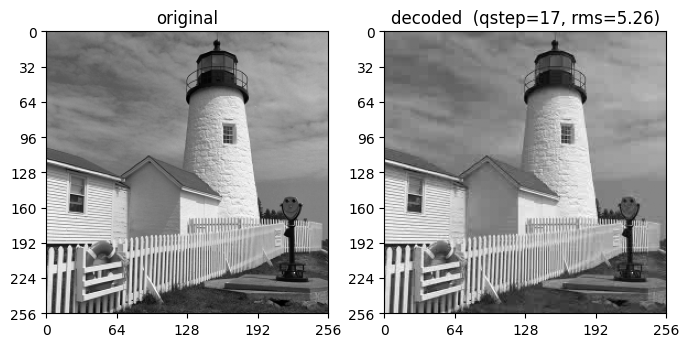

In [28]:
# Decode and confirm the round trip.
Z = jpegdec(vlc, qstep)
print(f'RMS error (JPEG round trip)  = {np.std(Z - X):.4f}')

# Check 1: identical to a plain DCT + centre-clipped quantiser (jpegenc uses rise1 = qstep),
#          so the scan / run-length / Huffman stages add no extra error.
from cued_sf2_lab.dct import dct_ii, colxfm
from cued_sf2_lab.laplacian_pyramid import quant1, quant2, bpp
C = dct_ii(8)
Yq = quant1(colxfm(colxfm(X, C).T, C).T, qstep, qstep)
Zd = colxfm(colxfm(quant2(Yq, qstep, qstep).T, C.T).T, C.T)
print(f'RMS error (direct quantiser) = {np.std(Zd - X):.4f}')

# Check 2: real coded bits vs the first-order entropy estimate.
coded, entropy = vlc[:, 1].sum(), bpp(Yq) * Yq.size
print(f'Coded = {coded} bits;  entropy estimate = {entropy:.0f} bits;  coded/entropy = {coded / entropy:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plot_image(X, ax=ax[0]); ax[0].set(title='original')
plot_image(Z, ax=ax[1]); ax[1].set(title=f'decoded  (qstep={qstep}, rms={np.std(Z - X):.2f})')

The two properties (the same checks the lab asks for your own coders):

1. **No extra error.** The JPEG round-trip RMS equals a plain DCT + centre-clipped quantiser
   with the same `rise1 = qstep`. The scan, run-length and Huffman stages are exactly
   invertible — all distortion comes from quantisation.
2. **Bits below entropy.** The coded size is _smaller_ than the first-order entropy estimate
   (`coded/entropy < 1`). Run-length coding exploits the **clustering** of non-zero
   coefficients — long zero-runs ended by one EOB — which per-symbol entropy ignores.

The next cell confirms both across all three test images.


In [29]:
# The same two checks across all three test images, computed live.
from cued_sf2_lab.dct import dct_ii, colxfm
from cued_sf2_lab.laplacian_pyramid import quant1, quant2, bpp
C = dct_ii(8)
print(f"{'image':<11}{'jpeg rms':>10}{'direct rms':>12}{'coded':>9}{'entropy':>9}{'ratio':>7}")
for name in ['lighthouse', 'bridge', 'flamingo']:
    Xi, _ = load_mat_img(img=f'{name}.mat', img_info='X')
    v, _ = jpegenc(Xi, qstep, log=False)
    Zi = jpegdec(v, qstep, log=False)
    Yq = quant1(colxfm(colxfm(Xi, C).T, C).T, qstep, qstep)
    Zd = colxfm(colxfm(quant2(Yq, qstep, qstep).T, C.T).T, C.T)
    coded = v[:, 1].sum(); ent = bpp(Yq) * Yq.size
    print(f"{name:<11}{np.std(Zi - Xi):>10.2f}{np.std(Zd - Xi):>12.2f}{coded:>9}{ent:>9.0f}{coded / ent:>7.2f}")

image        jpeg rms  direct rms    coded  entropy  ratio
lighthouse       5.26        5.26    67605    80781   0.84
bridge           7.03        7.03   102240   108739   0.94
flamingo         6.13        6.13    88863   103348   0.86


## Optimised Huffman tables

`jpegenc` can either use the default tables or, with `opthuff=True`, design custom tables from
the image's own symbol histogram (`huffdes`). A custom table must be **sent with the image**,
costing `(16 + 162) × 8 = 1424` bits. Whether that pays off depends on the per-image saving —
the next cell measures it.


In [30]:
# Is a per-image custom table worth its 1424-bit transmission cost?
TABLE_BITS = (16 + 162) * 8     # bits to send hufftab.bits + hufftab.huffval
print(f"{'image':<11}{'default':>9}{'opt+table':>11}{'net saving':>12}")
for name in ['lighthouse', 'bridge', 'flamingo']:
    Xi, _ = load_mat_img(img=f'{name}.mat', img_info='X')
    base = jpegenc(Xi, qstep, log=False)[0][:, 1].sum()
    opt = jpegenc(Xi, qstep, opthuff=True, log=False)[0][:, 1].sum()
    print(f"{name:<11}{base:>9}{opt + TABLE_BITS:>11}{base - (opt + TABLE_BITS):>12}")

image        default  opt+table  net saving
lighthouse     67605      65401        2204
bridge        102240      96955        5285
flamingo       88863      87542        1321


The custom table gives only a small net gain, because the fixed 1424-bit overhead erodes the
saving. For small images, mild quantisation, or one table reused across similar images, the
**default tables are often the better choice** — optimised design pays off only when the
per-image saving clearly exceeds the table cost. (At the competition's 40 960-bit budget, that
1424 bits is a real fraction of the total — worth checking per image.)


## Beyond JPEG and the DCT

With the DCT, coding follows the JPEG guidelines directly. Other front-ends need a modified
scan:

- **LBT** (the basis of JPEG-XR) is coded several sub-blocks at a time: a 4×4 LBT can be made
  to look like a 16×16 DCT via `regroup`. `jpegenc`/`jpegdec` already do this when the coding
  block size `M` exceeds the DCT size `N`.
- **DWT** (the basis of JPEG2000) is rearranged so coefficients from the same spatial area form
  a DCT-like block. `dwtgroup(X, n)` converts an `n`-level DWT into `2ⁿ × 2ⁿ` blocks with that
  grouping; `dwtgroup(X, -n)` reverses it. Try it on a small coordinate array to see the layout:


In [31]:
from cued_sf2_lab.jpeg import dwtgroup
# this is a nice trick to get an array of coordinates; use `display(x)` to check what this is doing
i, j = np.indices((8, 8))
x = np.rec.array((i, j))
print(dwtgroup(x, 2))

[[(0, 0) (0, 2) (0, 4) (0, 5) (0, 1) (0, 3) (0, 6) (0, 7)]
 [(2, 0) (2, 2) (1, 4) (1, 5) (2, 1) (2, 3) (1, 6) (1, 7)]
 [(4, 0) (4, 1) (4, 4) (4, 5) (4, 2) (4, 3) (4, 6) (4, 7)]
 [(5, 0) (5, 1) (5, 4) (5, 5) (5, 2) (5, 3) (5, 6) (5, 7)]
 [(1, 0) (1, 2) (2, 4) (2, 5) (1, 1) (1, 3) (2, 6) (2, 7)]
 [(3, 0) (3, 2) (3, 4) (3, 5) (3, 1) (3, 3) (3, 6) (3, 7)]
 [(6, 0) (6, 1) (6, 4) (6, 5) (6, 2) (6, 3) (6, 6) (6, 7)]
 [(7, 0) (7, 1) (7, 4) (7, 5) (7, 2) (7, 3) (7, 6) (7, 7)]]


With these scans, the same run-length / log-amplitude / Huffman coding applies to each vector.
(These scans are not optimal, and differ from the real JPEG2000 / JPEG-XR strategies.)

When you write your own `jpegenc` / `jpegdec` variants, verify:

1. **No extra error** — RMS between decoded and original equals the equivalent
   centre-clipped-quantiser result; the scan / Huffman stages add nothing.
2. **Bits ≈ entropy** — coded size within ~20% of the quantised-coefficient entropy (it can be
   _lower_, since run-length coding exploits zero-clustering that first-order entropy misses).
